In [67]:
# ── IMPORTS ───────────────────────────────────────────────────────────────────
import copy, time
import numpy as np
import cfgrib
import os
from tqdm import tqdm
import xarray as xr
import glob
import pandas as pd

In [68]:
path = 'C:\\Users\\maili\\Desktop\\KU\\AppMachineLearning\\Final_Project\\data\\'

In [69]:
 # delete all corrupted index files
idx_files = glob.glob(path + "*.idx")
for f in idx_files:
   os.remove(f)
   print(f"Deleted: {f}")

Deleted: C:\Users\maili\Desktop\KU\AppMachineLearning\Final_Project\data\grid-timeseries_sel_vars_1990.grib.5b7b6.idx


In [ ]:
filenames = [
    "grid-timeseries_sel_vars_2015.grib", "grid-timeseries_sel_vars_2016.grib",
    "grid-timeseries_sel_vars_2017.grib", "grid-timeseries_sel_vars_2018.grib",
    "grid-timeseries_sel_vars_2019.grib", "grid-timeseries_sel_vars_2020.grib",
    "grid-timeseries_sel_vars_2021.grib", "grid-timeseries_sel_vars_2022.grib",
    "grid-timeseries_sel_vars_2023.grib", "grid-timeseries_sel_vars_2024.grib",
    "grid-timeseries_sel_vars_2025.grib", "grid-timeseries_sel_vars_2026_april.grib"
]

#filenames = ["grid-timeseries_sel_vars_1980.grib"]


all_ds0, all_ds1 = [], []

for fname in filenames:
    fpath = path + fname
    print(f"Opening {fname}...")
    datasets = cfgrib.open_datasets(fpath)

    ds0 = next((d for d in datasets if 'sp' in d.data_vars), None)
    ds1 = next((d for d in datasets if 'tp' in d.data_vars), None)

    if ds0 is None or ds1 is None:
        print(f"  ✗ missing ds0 or ds1 in {fname}")
        continue

    all_ds0.append(ds0)
    all_ds1.append(ds1)
    print(f"  ✓ ds0 vars: {list(ds0.data_vars)} | ds1 vars: {list(ds1.data_vars)}")

# concatenate across years
ds0 = xr.concat(all_ds0, dim="time", compat = "override", coords="minimal")
ds1 = xr.concat(all_ds1, dim="time", compat = "override", coords="minimal")

# match original variable names
ref_lat  = ds0.latitude.values
ref_lon  = ds0.longitude.values
ref_time = ds0.time

print("\nds0:", ds0)
print("\nds1:", ds1)
print("\nTime range:", ref_time.values[0], "→", ref_time.values[-1])
print("Total timesteps:", len(ref_time))


Opening grid-timeseries_sel_vars_1980.grib...


c:\Users\maili\anaconda3\envs\weather\Lib\site-packages\cfgrib\xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
c:\Users\maili\anaconda3\envs\weather\Lib\site-packages\cfgrib\xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
c:\Users\maili

  ✓ ds0 vars: ['sp', 'tcc', 'u10', 'v10', 't2m'] | ds1 vars: ['ssrd', 'tp']

ds0: <xarray.Dataset> Size: 5MB
Dimensions:     (time: 8784, latitude: 5, longitude: 5)
Coordinates:
  * time        (time) datetime64[ns] 70kB 1980-01-01 ... 1980-12-31T23:00:00
    valid_time  (time) datetime64[ns] 70kB 1980-01-01 ... 1980-12-31T23:00:00
  * latitude    (latitude) float64 40B 56.0 55.75 55.5 55.25 55.0
  * longitude   (longitude) float64 40B 12.0 12.25 12.5 12.75 13.0
    number      int64 8B 0
    step        timedelta64[ns] 8B 00:00:00
    surface     float64 8B 0.0
Data variables:
    sp          (time, latitude, longitude) float32 878kB 9.96e+04 ... 9.941e+04
    tcc         (time, latitude, longitude) float32 878kB 1.0 0.9716 ... 0.8027
    u10         (time, latitude, longitude) float32 878kB 2.164 1.776 ... 16.45
    v10         (time, latitude, longitude) float32 878kB -4.103 ... -1.58
    t2m         (time, latitude, longitude) float32 878kB 273.6 273.4 ... 277.3
Attributes:
    GRI

In [71]:
def flatten_and_diff(ds, var, clip_zero=True):
    base  = pd.to_datetime(ds.time.values).to_numpy()
    steps = pd.to_timedelta(ds.step.values).to_numpy()
    valid_times = (base[:, None] + steps[None, :]).reshape(-1)
    data = ds[var].values                                          # (N_init, 12, 5, 5)
    data_diff = np.concatenate([data[:, :1], np.diff(data, axis=1)], axis=1)
    if clip_zero:
        data_diff = np.clip(data_diff, 0, None)
    data_diff = data_diff.reshape(-1, 5, 5)
    da = xr.DataArray(data_diff,
                      dims=["time", "latitude", "longitude"],
                      coords={"time": valid_times,
                              "latitude": ds.latitude.values,
                              "longitude": ds.longitude.values}, name=var)
    da = da.sortby("time")
    _, first_occ = np.unique(da.time.values, return_index=True)
    da = da.isel(time=first_occ)
    da = da.interpolate_na(dim="time", method="linear", 
                           max_gap=np.timedelta64(24, 'h'))
    da = da.fillna(0.0)
    return da


tp_flat   = flatten_and_diff(ds1, "tp")
ssrd_flat = flatten_and_diff(ds1, "ssrd")


print("tp_flat shape:", tp_flat.shape)
print("ssrd_flat shape:", ssrd_flat.shape)
print("tp_flat NaNs:", np.isnan(tp_flat.values).sum())
print("tp sample values (centre pixel, mm):", tp_flat.values[:5, 2, 2] * 1000)
print("tp max (mm):", tp_flat.values.max() * 1000)


tp_flat shape: (8796, 5, 5)
ssrd_flat shape: (8796, 5, 5)
tp_flat NaNs: 0
tp sample values (centre pixel, mm): [0. 0. 0. 0. 0.]
tp max (mm): 5.906105


In [72]:
def dedup(da):
    _, idx = np.unique(da.time.values, return_index=True)
    return da.isel(time=idx)

tp_flat   = dedup(tp_flat)
ssrd_flat = dedup(ssrd_flat)
ds0       = dedup(ds0)
common = np.intersect1d(ds0.time.values, tp_flat.time.values) # alignwith common timesteps
print(f"Common timesteps: {len(common)}")

ds0       = ds0.sel(time=common)
tp_flat   = tp_flat.sel(time=common)
ssrd_flat = ssrd_flat.sel(time=common)

ds1_clean = xr.Dataset({"tp": tp_flat, "ssrd": ssrd_flat})


Common timesteps: 8784


In [ ]:
print("ds0 sp shape :", ds0["sp"].shape)
print("tp shape     :", tp_flat.shape)
print("ssrd shape   :", ssrd_flat.shape)
print("tp NaNs      :", int(np.isnan(tp_flat.values).sum()))
print("ssrd NaNs    :", int(np.isnan(ssrd_flat.values).sum()))
print("tp min/max   :", float(tp_flat.min()), float(tp_flat.max()))

ds0 sp shape : (8784, 5, 5)
tp shape     : (8784, 5, 5)
ssrd shape   : (8784, 5, 5)
tp NaNs      : 0
ssrd NaNs    : 0
tp min/max   : 0.0 0.005906105041503906


In [74]:
ds0.to_netcdf("data\\ds0_all_years_deacc_1980.nc")
ds1_clean.to_netcdf("data\\ds1_all_years_deacc_1980.nc")

In [ ]:
print("ssrd NaNs:", np.isnan(ssrd_flat.values).sum())
print("ssrd min/max (W/m²·s → J/m²):", ssrd_flat.values.min(), ssrd_flat.values.max())
print("ssrd sample (centre pixel, first 24h):", ssrd_flat.values[:24, 2, 2])

ssrd NaNs: 0
ssrd min/max (W/m²·s → J/m²): 0.0 1.543424e+06
ssrd sample (centre pixel, first 24h): [     0.      0.      0.      0.      0.      0.      0.      0.   3136.
  90240. 111040. 141824.  56320.      0.      0.      0.      0.      0.
      0.      0.      0.      0.      0.      0.]


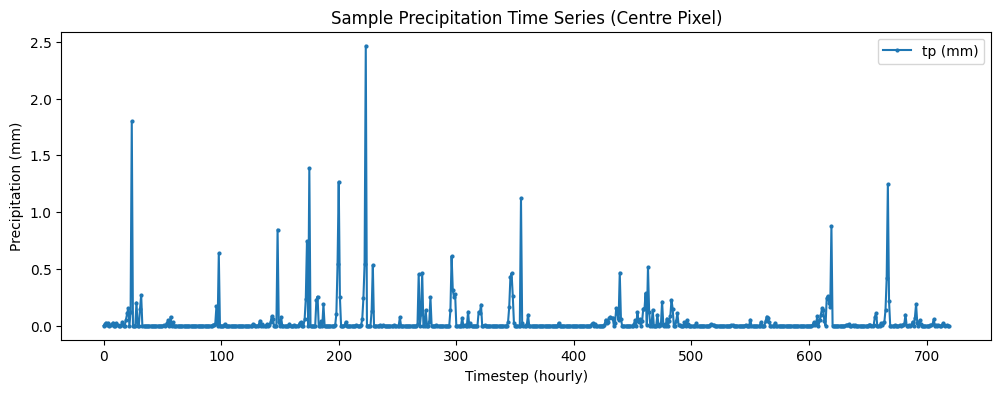

In [78]:
# plot precipitation data
prec = ds1['tp'].values.reshape(-1, 5, 5)[:, 2, 2] * 1000  # mm
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.plot(prec[:24*30], label="tp (mm)", marker='o', markersize=2)
plt.title("Sample Precipitation Time Series (Centre Pixel)")
plt.xlabel("Timestep (hourly)")
plt.ylabel("Precipitation (mm)")
plt.legend()
plt.show()